In [17]:
print("heloo")

heloo


In [18]:
# Install dependencies if needed
# !pip install pypdf --break-system-packages

import pypdf
import os

def extract_resume_text(pdf_path: str) -> str:
    if not os.path.exists(pdf_path):
        return ""
    try:
        reader = pypdf.PdfReader(pdf_path)
        return "\n".join([page.extract_text() for page in reader.pages])
    except Exception as e:
        print(f"Error reading PDF: {e}")
        return ""

In [19]:
from typing import List, Dict, Optional, Literal, Annotated
from typing_extensions import TypedDict
from langgraph.types import interrupt, Command
from pydantic import BaseModel, Field

from langchain_groq import ChatGroq
from langchain_core.messages import BaseMessage, HumanMessage, AIMessage, SystemMessage

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.checkpoint.memory import InMemorySaver
from dotenv import load_dotenv
import os

load_dotenv()
groq_api=os.getenv("Groq_Api_key")
llm = ChatGroq(
    model="llama-3.1-8b-instant",
    temperature=0,
    max_retries=2,
    api_key=groq_api

)

In [20]:
llm.invoke("hi")

AIMessage(content='How can I assist you today?', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 8, 'prompt_tokens': 36, 'total_tokens': 44, 'completion_time': 0.006534007, 'completion_tokens_details': None, 'prompt_time': 0.001605845, 'prompt_tokens_details': None, 'queue_time': 0.157170383, 'total_time': 0.008139852}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_7ccc667439', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019d5856-d78c-7822-8af0-d9015e0daf79-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 36, 'output_tokens': 8, 'total_tokens': 44})

In [21]:
class AnswerEvaluation(BaseModel):
    score: int = Field(description="Score from 1 to 10")
    strengths: List[str] = Field(description="List of positive points")
    weaknesses: List[str] = Field(description="List of negative points/gaps")
    missed_points: List[str] = Field(description="Key points that were not mentioned")
    should_follow_up: bool = Field(description="Whether to ask a follow-up question")
    is_unfamiliar: bool = Field(description="Set to True ONLY if candidate explicitly says 'don't know' or 'not familiar'")
    follow_up_focus: str = Field(description="What to focus on in follow-up, or empty string")
    feedback: str = Field(description="Short feedback for the candidate")


In [22]:
class InterviewState(TypedDict):
    messages: Annotated[List[BaseMessage], add_messages]
    role: str
    candidate_name: str
    tech_stack: List[str]
    focus_areas: List[str]
    resume_text: str
    strikes: int
    current_topic: str
    current_difficulty: Literal["easy", "medium", "hard"]
    latest_question: str
    latest_answer: str
    latest_evaluation: Optional[Dict]
    interview_log: List[Dict]
    asked_topics: List[str]
    question_count: int
    max_questions: int
    next_action: str
    final_report: Optional[Dict]


In [36]:
def format_history(interview_log: List[Dict]) -> str:
    if not interview_log:
        return "No interview history yet."

    blocks = []
    for i, item in enumerate(interview_log, start=1):
        strengths = ", ".join(item.get('strengths', [])) if isinstance(item.get('strengths'), list) else item.get('strengths', "")
        weaknesses = ", ".join(item.get('weaknesses', [])) if isinstance(item.get('weaknesses'), list) else item.get('weaknesses', "")
        
        blocks.append(
            f"""Round {i}
Question: {item['question']}
Topic: {item['topic']}
Difficulty: {item['difficulty']}
Answer: {item['answer']}
Score: {item['score']}
Strengths: {strengths}
Weaknesses: {weaknesses}
Feedback: {item['feedback']}"""
        )
    return "\n\n".join(blocks)


def remaining_topics(focus_areas: List[str], asked_topics: List[str]) -> List[str]:
    asked = {x.lower() for x in asked_topics}
    return [topic for topic in focus_areas if topic.lower() not in asked]


In [37]:
question_llm = llm.with_structured_output(InterviewQuestion)

def interviewer_agent(state: InterviewState):
    history = format_history(state["interview_log"])
    uncovered = remaining_topics(state["focus_areas"], state["asked_topics"])
    latest_eval = state.get("latest_evaluation") or {}

    prompt = f"""
You are a technical interviewer.

Candidate name: {state['candidate_name']}
Target role: {state['role']}
Tech stack: {', '.join(state['tech_stack'])}
Focus areas: {', '.join(state['focus_areas'])}
Current topic preference: {state['current_topic']}
Current difficulty: {state['current_difficulty']}
Remaining uncovered topics: {uncovered}
    Resume content: {state.get("resume_text", "Not provided")}
Latest evaluation: {latest_eval}

Previous history:
{history}

Instructions:
- Ask exactly one interview question.
- Make it realistic and concise.
- Avoid repeating earlier questions.
- If the previous answer was weak and should_follow_up is true, ask a follow-up.
- If the candidate was not familiar with the previous topic, try a simpler question or a related entry-level topic.
- Use the resume content to tailor questions to the candidate's experience.
- Otherwise prefer uncovered topics.
- Return structured output only.
"""

    result = question_llm.invoke([
        SystemMessage(content=prompt),
        HumanMessage(content="Generate the next interview question.")
    ])

    user_answer = interrupt({
        "question": result.question,
        "topic": result.topic,
        "difficulty": result.difficulty
    })

    return {
        "latest_question": result.question,
        "current_topic": result.topic,
        "current_difficulty": result.difficulty,
        "latest_answer": user_answer,
        "messages": [AIMessage(content=result.question), HumanMessage(content=user_answer)],
        "next_action": "evaluate"
    }

In [38]:
evaluation_llm = llm.with_structured_output(AnswerEvaluation)

def evaluator_agent(state: InterviewState):
    prompt = f"""
Evaluate this technical interview response.

Role: {state['role']}
Question: {state['latest_question']}
Topic: {state['current_topic']}
Difficulty: {state['current_difficulty']}
Candidate answer: {state['latest_answer']}

EVALUATION CRITERIA:
- score: 1-10 (strict but fair).
- is_unfamiliar: True if candidate says 'I don't know', 'not familiar', or equivalent. False otherwise.
- follow_up_focus: if should_follow_up is True, provide a focus string.

Return the evaluation using the AnswerEvaluation tool call with correct JSON boolean values (true/false).
"""

    result = evaluation_llm.invoke([
        SystemMessage(content=prompt),
        HumanMessage(content="Evaluate the candidate's answer now.")
    ])

    log_item = {
        "question": state["latest_question"],
        "answer": state["latest_answer"],
        "topic": state["current_topic"],
        "difficulty": state["current_difficulty"],
        "score": result.score,
        "strengths": result.strengths,
        "weaknesses": result.weaknesses,
        "missed_points": result.missed_points,
        "feedback": result.feedback
    }
    new_strikes = state.get("strikes", 0) + (1 if result.is_unfamiliar else 0)

    return {
        "latest_evaluation": result.model_dump(),
        "strikes": new_strikes,
        "interview_log": state["interview_log"] + [log_item],
        "asked_topics": state["asked_topics"] + [state["current_topic"]],
        "question_count": state["question_count"] + 1,
        "messages": [AIMessage(content=f"Evaluation done. Score: {result.score}/10")],
        "next_action": "supervise"
    }

In [39]:
def supervisor_agent(state: InterviewState):
    latest_eval = state.get("latest_evaluation") or {}
    uncovered = remaining_topics(state["focus_areas"], state["asked_topics"])

    prompt = f"""
You are the supervisor of a mock interview system.

Role: {state['role']}
Question count: {state['question_count']}
Max questions: {state['max_questions']}
Current topic: {state['current_topic']}
Current difficulty: {state['current_difficulty']}
Remaining uncovered topics: {uncovered}
Latest evaluation: {latest_eval}
Current Strikes: {state.get('strikes', 0)}

Rules:
- If question_count >= max_questions, end the interview.
- If strikes >= 5, end the interview immediately.
- If latest score is low, keep same or lower difficulty.
- If latest score is high, increase difficulty or move to a new topic.
- Try to cover focus areas before ending.
- Return structured output only.
"""

    result = supervisor_llm.invoke([
        SystemMessage(content=prompt),
        HumanMessage(content="Decide the next step.")
    ])

    # End interview if strikes reached limit
    if state.get("strikes", 0) >= 5:
        result.next_step = "end"

    # Calculate next difficulty
    next_diff = result.next_difficulty
    if latest_eval.get("is_unfamiliar"):
        diff_map = {"hard": "medium", "medium": "easy", "easy": "easy"}
        next_diff = diff_map.get(state["current_difficulty"], "easy")

    final_report = None
    if result.next_step == "end":
        scores = [item["score"] for item in state["interview_log"] if "score" in item]
        avg_score = round(sum(scores) / len(scores), 2) if scores else 0
        final_report = {
            "candidate_name": state["candidate_name"],
            "role": state["role"],
            "questions_answered": state["question_count"],
            "total_strikes": state.get("strikes", 0),
            "average_score": avg_score,
            "logs": state["interview_log"]
        }

    return {
        "current_topic": result.next_topic or state["current_topic"],
        "current_difficulty": next_diff,
        "next_action": result.next_step,
        "final_report": final_report,
        "messages": [AIMessage(content=f"Supervisor decision: {result.next_step}")]
    }

In [40]:
# def route_after_input(state: InterviewState):
#     if state.get("latest_answer", "").strip():
#         return "evaluate"
#     return "ask"


def route_after_supervisor(state: InterviewState):
    if state.get("next_action") == "end":
        return "end"
    return "ask"

In [41]:
# def ingest_user_input(state: InterviewState):
#     return state


def end_node(state: InterviewState):
    report = state.get("final_report") or {}
    avg = report.get("average_score", "N/A")
    return {
        "messages": [AIMessage(content=f"Interview ended. Average score: {avg}")]
    }

In [42]:
builder = StateGraph(InterviewState)

builder.add_node("interviewer", interviewer_agent)
builder.add_node("evaluator", evaluator_agent)
builder.add_node("supervisor", supervisor_agent)
builder.add_node("end_node", end_node)

builder.add_edge(START, "interviewer")
builder.add_edge("interviewer", "evaluator")
builder.add_edge("evaluator", "supervisor")

builder.add_conditional_edges(
    "supervisor",
    route_after_supervisor,
    {
        "ask": "interviewer",
        "end": "end_node"
    }
)

builder.add_edge("end_node", END)

memory = InMemorySaver()
graph = builder.compile(checkpointer=memory)

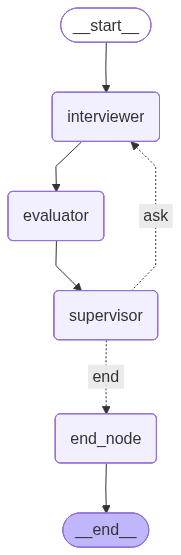

In [43]:
graph

In [44]:
def get_initial_state(
    role: str,
    candidate_name: str,
    tech_stack: List[str],
    focus_areas: List[str],
    resume_text: str = "",
    max_questions: int = 5
):
    start_topic = focus_areas[0] if focus_areas else "general"

    return {
        "messages": [],
        "role": role,
        "candidate_name": candidate_name,
        "tech_stack": tech_stack,
        "focus_areas": focus_areas,
        "resume_text": resume_text,
        "strikes": 0,
        "current_topic": start_topic,
        "current_difficulty": "easy",
        "latest_question": "",
        "latest_answer": "",
        "latest_evaluation": None,
        "interview_log": [],
        "asked_topics": [],
        "question_count": 0,
        "max_questions": max_questions,
        "next_action": "",
        "final_report": None
    }

In [45]:
def start_interview(thread_id: str, resume_content: str = ""):
    state = get_initial_state(
        role="Backend Developer",
        candidate_name="Vinay",
        tech_stack=["Java", "Spring Boot", "SQL", "Redis"],
        focus_areas=["Java", "OOP", "DBMS", "System Design"],
        resume_text=resume_content,
        max_questions=10
    )

    config = {"configurable": {"thread_id": thread_id}}
    result = graph.invoke(state, config=config)
    return result

In [47]:
## Example of how to run the interview with resume
import os
resume_file = "resume_text.txt"
resume_content = ""
if os.path.exists(resume_file):
    with open(resume_file, "r") as f:
        resume_content = f.read()

thread_id = "test_thread_resume_1"
config = {"configurable": {"thread_id": thread_id}}

# 1. Start the interview
print("--- Starting Interview ---")
result = start_interview(thread_id, resume_content=resume_content)

## In LangGraph v0.2+, if an interrupt is hit, the question is in the state tasks:
state = graph.get_state(config)
if state.next:
    # Get the payload passed to 'interrupt()'
    interrupt_payload = state.tasks[0].interrupts[0].value
    print(f"\n--- FIRST QUESTION ---")
    print(f"Topic: {interrupt_payload['topic']} | Difficulty: {interrupt_payload['difficulty']}")
    print(f"Question: {interrupt_payload['question']}")
else:
    print("Graph finished without interruption (check if thread already finished)")

--- Starting Interview ---

--- FIRST QUESTION ---
Topic: Java | Difficulty: easy
Question: Can you explain the concept of encapsulation in Java and provide an example?


In [50]:
## TO CONTINUE THE INTERVIEW: Run this cell and enter your answer
## You can run this multiple times for each follow-up

from langgraph.types import Command

user_answer = input("Enter your answer (or say 'I am not familiar with this'): ")

result = graph.invoke(Command(resume=user_answer), config=config)

# 1. If it hits another interrupt (new question)
if isinstance(result, dict) and "question" in result:
    print(f"\n--- NEXT QUESTION ---")
    print(f"Topic: {result['topic']} | Difficulty: {result['difficulty']}")
    print(f"Question: {result['question']}")

# 2. If it reaches the end node
else:
    current_state = graph.get_state(config).values
    report = current_state.get('final_report')
    if report:
        print("\n--- INTERVIEW COMPLETE ---")
        print(f"Candidate: {report['candidate_name']}")
        print(f"Average Score: {report['average_score']}/10")
        print(f"Total Strikes: {report['total_strikes']}")
        print(f"Questions Answered: {report['questions_answered']}")

BadRequestError: Error code: 400 - {'error': {'message': "Failed to call a function. Please adjust your prompt. See 'failed_generation' for more details.", 'type': 'invalid_request_error', 'code': 'tool_use_failed', 'failed_generation': '<function=AnswerEvaluation> {"score": 1, "feedback": "The candidate explicitly stated they are not familiar with the concept of encapsulation in Java, which is a fundamental concept in object-oriented programming.", "is_unfamiliar": True, "missed_points": ["Lack of knowledge about encapsulation in Java", "Failed to provide an example"], "strengths": [], "weaknesses": ["Lack of knowledge about a fundamental concept in Java"], "should_follow_up": True} </function>'}}

In [51]:
# thread_id = "mock-interview-1"

# result = start_interview(thread_id)
# result